### Applying CNN architecture to a larger dataset

* Why Larger Dataset? 
    * larger datasets like CIFAR 10 or Fashion MNIST Represent more realistic and diverse challenges compared to toy datasets like MNIST
    * They require deeper achitecutures , careful regularization and augmentation for optimal performance

### Experimenting with architecture design , regularization and augmentation

* key techniques to improve performance
    * Architectural Modifications
        * Add more convolutional alyers or change kernel size
        * Use more filters in deeper layers to captures complex features
    * Regularization
        * Apply Droput in dense layers and batch normalization in covn layers
        * prevent overfitting
    * Data Augmentation
        * Use techniques like random flipping, cropping , and rotation to improve generalization
    
### Analyzing model performance and tuning
* Evaluation metrics
    * Accuracy : overall classification correctness
    * Loss: Measure the difference between predictions and ground truth
    * Confusion Matrix : Highlights misclassified classes for deeper insights
    

In [9]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


In [2]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip()
    ,transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5 , 0.5),(0.5, 0.5 , 0.5))
])

transform_test = transforms.Compose([ transforms.ToTensor(),
                                     transforms.Normalize((0.5,0.5,0.5),(0.5, 0.5, 0.5))])

In [ ]:
# Load CIFAR-10 datasets
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

100%|██████████| 170M/170M [00:03<00:00, 45.5MB/s] 


In [4]:
train_loader = DataLoader(train_dataset,batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=64, shuffle=False)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

Number of training samples: 50000
Number of test samples: 10000


In [18]:
# Define the CNN architecture
class EnhancedCNN(nn.Module):
    def __init__(self):
        super(EnhancedCNN, self).__init__()
        self.conv1 = nn.Conv2d(3,6,5)  # 3 input channels (RGB), 6 output channels, 5x5 kernel
        self.bn1 = nn.BatchNorm2d(6) # Batch normalization for the first conv layer
        self.conv2 = nn.Conv2d(6,16,5) # 6 input channels, 16 output channels, 5x5 kernel
        self.bn2 = nn.BatchNorm2d(16) # Batch normalization for the second conv layer
        self.pool = nn.MaxPool2d(2,2) # Max pooling layer with 2x2 kernel
        self.dropout = nn.Dropout(0.5) # Dropout layer with 50% dropout rate

        # Calculate the size of the input output from the conv layer dynamically
        self.__calculate_conv_output()

        self.fc1 =  nn.Linear(self.conv_output_size,128)
        self.fc2 = nn.Linear(128,84)
        self.fc3 = nn.Linear(84,10)
    def __calculate_conv_output(self):
        # Dummy Input Tensor witht the same size as the input images
        dummy_input = torch.zeros(1,3,32,32)
        with torch.no_grad():
            output = self.pool(F.relu(self.bn2(self.conv2(F.relu(self.bn1(self.conv1(dummy_input)))))))
        self.conv_output_size = output.numel()
    def forward(self,x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0),-1) # Flatten the tensor dynamically
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = EnhancedCNN()

print(model)


EnhancedCNN(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (bn1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=2304, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [19]:
#  Train the model
# Define optimizer and loss
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training
training_loss = []
def train_model(model,train_loader, criterion, optimizer, epochs = 20):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs,labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        epoch_loss = running_loss/len(train_loader)
        training_loss.append(epoch_loss)
        print(f"Epoch {epoch+1} , loss: {epoch_loss}")
train_model(model,train_loader, criterion, optimizer)




Epoch 1 , loss: 1.767699431885234
Epoch 2 , loss: 1.5882996092062167
Epoch 3 , loss: 1.4937102692511381
Epoch 4 , loss: 1.4295176361375452
Epoch 5 , loss: 1.3864295937673514
Epoch 6 , loss: 1.3557141536032147
Epoch 7 , loss: 1.3291534899598192
Epoch 8 , loss: 1.3118776842151456
Epoch 9 , loss: 1.2920182699437641
Epoch 10 , loss: 1.2856933320574748
Epoch 11 , loss: 1.2729008903588785
Epoch 12 , loss: 1.2650844161315342
Epoch 13 , loss: 1.260868033027405
Epoch 14 , loss: 1.256301929502536
Epoch 15 , loss: 1.2412901547406336
Epoch 16 , loss: 1.2327002278526726
Epoch 17 , loss: 1.2316302659414005
Epoch 18 , loss: 1.2279176219649937
Epoch 19 , loss: 1.2193610431897977
Epoch 20 , loss: 1.212894003714442


In [20]:
# Evaluation loop
def evaluate_model(model,test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for image,labels in test_loader:
            outputs = model(image)
            _, predicted = torch.max(outputs,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"Test Accuracy: {100 * correct / total:.3f}")

evaluate_model(model, test_loader)


Test Accuracy: 64.630


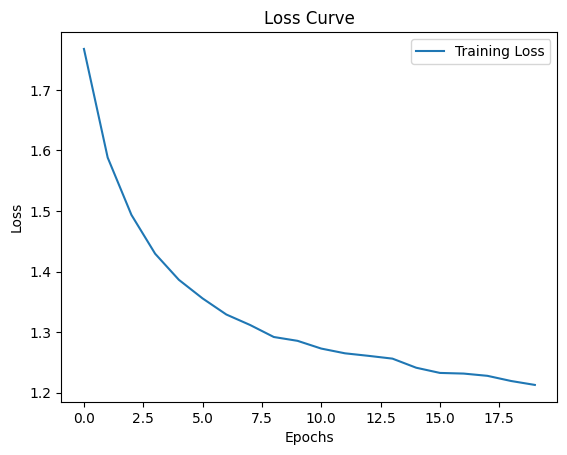

In [21]:
import matplotlib.pyplot as plt
plt.plot(training_loss  , label="Training Loss")
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()